# modle loading

In [ ]:
import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")



from langchain.chat_models import init_chat_model
import os



llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)

response = llm.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)


llm = init_chat_model(
    "ollama:nemotron-3-super:cloud",
    base_url="https://ollama.com",
)

response = llm.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)

# tool definition

In [2]:
from typing import Literal
from datetime import datetime
from pydantic import BaseModel
from langchain_core.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool

# state

In [10]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, AIMessage

class State(MessagesState):
    # We can add a specific key to our state for the email input 
    email_input: dict
    classification_decision: Literal["ignore", "respond", "notify"]

In [11]:
state = State(
    messages=[
        HumanMessage(content="Hello")
    ],
    email_input={
        "subject": "Meeting",
        "body": "Let's meet tomorrow"
    },
    classification_decision="notify"
)

In [12]:
state

{'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={})],
 'email_input': {'subject': 'Meeting', 'body': "Let's meet tomorrow"},
 'classification_decision': 'notify'}

# prompts

In [1]:
from datetime import datetime

# Email assistant triage prompt 
triage_system_prompt = """

< Role >
Your role is to triage incoming emails based upon instructs and background information below.
</ Role >

< Background >
{background}. 
</ Background >

< Instructions >
Categorize each email into one of three categories:
1. IGNORE - Emails that are not worth responding to or tracking
2. NOTIFY - Important information that worth notification but doesn't require a response
3. RESPOND - Emails that need a direct response
Classify the below email into one of these categories.
</ Instructions >

< Rules >
{triage_instructions}
</ Rules >
"""

# Email assistant triage user prompt 
triage_user_prompt = """
Please determine how to handle the below email thread:

From: {author}
To: {to}
Subject: {subject}
{email_thread}"""

# Email assistant prompt 
agent_system_prompt = """
< Role >
You are a top-notch executive assistant who cares about helping your executive perform as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage communications and schedule:
{tools_prompt}
</ Tools >

< Instructions >
When handling emails, follow these steps:
1. Carefully analyze the email content and purpose
2. IMPORTANT --- always call a tool and call one tool at a time until the task is complete: 
3. For responding to the email, draft a response email with the write_email tool
4. For meeting requests, use the check_calendar_availability tool to find open time slots
5. To schedule a meeting, use the schedule_meeting tool with a datetime object for the preferred_day parameter
   - Today's date is """ + datetime.now().strftime("%Y-%m-%d") + """ - use this for scheduling meetings accurately
6. If you scheduled a meeting, then draft a short response email using the write_email tool
7. After using the write_email tool, the task is complete
8. If you have sent the email, then use the Done tool to indicate that the task is complete
</ Instructions >

< Background >
{background}
</ Background >

< Response Preferences >
{response_preferences}
</ Response Preferences >

< Calendar Preferences >
{cal_preferences}
</ Calendar Preferences >
"""

# Email assistant with HITL prompt 
agent_system_prompt_hitl = """
< Role >
You are a top-notch executive assistant who cares about helping your executive perform as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage communications and schedule:
{tools_prompt}
</ Tools >

< Instructions >
When handling emails, follow these steps:
1. Carefully analyze the email content and purpose
2. IMPORTANT --- always call a tool and call one tool at a time until the task is complete: 
3. If the incoming email asks the user a direct question and you do not have context to answer the question, use the Question tool to ask the user for the answer
4. For responding to the email, draft a response email with the write_email tool
5. For meeting requests, use the check_calendar_availability tool to find open time slots
6. To schedule a meeting, use the schedule_meeting tool with a datetime object for the preferred_day parameter
   - Today's date is """ + datetime.now().strftime("%Y-%m-%d") + """ - use this for scheduling meetings accurately
7. If you scheduled a meeting, then draft a short response email using the write_email tool
8. After using the write_email tool, the task is complete
9. If you have sent the email, then use the Done tool to indicate that the task is complete
</ Instructions >

< Background >
{background}
</ Background >

< Response Preferences >
{response_preferences}
</ Response Preferences >

< Calendar Preferences >
{cal_preferences}
</ Calendar Preferences >
"""

# Email assistant with HITL and memory prompt 
# Note: Currently, this is the same as the HITL prompt. However, memory specific tools (see https://langchain-ai.github.io/langmem/) can be added  
agent_system_prompt_hitl_memory = """
< Role >
You are a top-notch executive assistant. 
</ Role >

< Tools >
You have access to the following tools to help manage communications and schedule:
{tools_prompt}
</ Tools >

< Instructions >
When handling emails, follow these steps:
1. Carefully analyze the email content and purpose
2. IMPORTANT --- always call a tool and call one tool at a time until the task is complete: 
3. If the incoming email asks the user a direct question and you do not have context to answer the question, use the Question tool to ask the user for the answer
4. For responding to the email, draft a response email with the write_email tool
5. For meeting requests, use the check_calendar_availability tool to find open time slots
6. To schedule a meeting, use the schedule_meeting tool with a datetime object for the preferred_day parameter
   - Today's date is """ + datetime.now().strftime("%Y-%m-%d") + """ - use this for scheduling meetings accurately
7. If you scheduled a meeting, then draft a short response email using the write_email tool
8. After using the write_email tool, the task is complete
9. If you have sent the email, then use the Done tool to indicate that the task is complete
</ Instructions >

< Background >
{background}
</ Background >

< Response Preferences >
{response_preferences}
</ Response Preferences >

< Calendar Preferences >
{cal_preferences}
</ Calendar Preferences >
"""

# Default background information 
default_background = """ 
I'm Lance, a software engineer at LangChain.
"""

# Default response preferences 
default_response_preferences = """
Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and reference the deadline in your response.

When responding to technical questions that require investigation:
- Clearly state whether you will investigate or who you will ask
- Provide an estimated timeline for when you'll have more information or complete the task

When responding to event or conference invitations:
- Always acknowledge any mentioned deadlines (particularly registration deadlines)
- If workshops or specific topics are mentioned, ask for more specific details about them
- If discounts (group or early bird) are mentioned, explicitly request information about them
- Don't commit 

When responding to collaboration or project-related requests:
- Acknowledge any existing work or materials mentioned (drafts, slides, documents, etc.)
- Explicitly mention reviewing these materials before or during the meeting
- When scheduling meetings, clearly state the specific day, date, and time proposed

When responding to meeting scheduling requests:
- If times are proposed, verify calendar availability for all time slots mentioned in the original email and then commit to one of the proposed times based on your availability by scheduling the meeting. Or, say you can't make it at the time proposed.
- If no times are proposed, then check your calendar for availability and propose multiple time options when available instead of selecting just one.
- Mention the meeting duration in your response to confirm you've noted it correctly.
- Reference the meeting's purpose in your response.
"""

# Default calendar preferences 
default_cal_preferences = """
30 minute meetings are preferred, but 15 minute meetings are also acceptable.
"""

# Default triage instructions 
default_triage_instructions = """
Emails that are not worth responding to:
- Marketing newsletters and promotional emails
- Spam or suspicious emails
- CC'd on FYI threads with no direct questions

There are also other things that should be known about, but don't require an email response. For these, you should notify (using the `notify` response). Examples of this include:
- Team member out sick or on vacation
- Build system notifications or deployments
- Project status updates without action items
- Important company announcements
- FYI emails that contain relevant information for current projects
- HR Department deadline reminders
- Subscription status / renewal reminders
- GitHub notifications

Emails that are worth responding to:
- Direct questions from team members requiring expertise
- Meeting requests requiring confirmation
- Critical bug reports related to team's projects
- Requests from management requiring acknowledgment
- Client inquiries about project status or features
- Technical questions about documentation, code, or APIs (especially questions about missing endpoints or features)
- Personal reminders related to family (wife / daughter)
- Personal reminder related to self-care (doctor appointments, etc)
"""

MEMORY_UPDATE_INSTRUCTIONS = """
# Role and Objective
You are a memory profile manager for an email assistant agent that selectively updates user preferences based on feedback messages from human-in-the-loop interactions with the email assistant.

# Instructions
- NEVER overwrite the entire memory profile
- ONLY make targeted additions of new information
- ONLY update specific facts that are directly contradicted by feedback messages
- PRESERVE all other existing information in the profile
- Format the profile consistently with the original style
- Generate the profile as a string

# Reasoning Steps
1. Analyze the current memory profile structure and content
2. Review feedback messages from human-in-the-loop interactions
3. Extract relevant user preferences from these feedback messages (such as edits to emails/calendar invites, explicit feedback on assistant performance, user decisions to ignore certain emails)
4. Compare new information against existing profile
5. Identify only specific facts to add or update
6. Preserve all other existing information
7. Output the complete updated profile

# Example
<memory_profile>
RESPOND:
- wife
- specific questions
- system admin notifications
NOTIFY: 
- meeting invites
IGNORE:
- marketing emails
- company-wide announcements
- messages meant for other teams
</memory_profile>

<user_messages>
"The assistant shouldn't have responded to that system admin notification."
</user_messages>

<updated_profile>
RESPOND:
- wife
- specific questions
NOTIFY: 
- meeting invites
- system admin notifications
IGNORE:
- marketing emails
- company-wide announcements
- messages meant for other teams
</updated_profile>

# Process current profile for {namespace}
<memory_profile>
{current_profile}
</memory_profile>

Think step by step about what specific feedback is being provided and what specific information should be added or updated in the profile while preserving everything else.

Think carefully and update the memory profile based upon these user messages:"""

MEMORY_UPDATE_INSTRUCTIONS_REINFORCEMENT = """
Remember:
- NEVER overwrite the entire memory profile
- ONLY make targeted additions of new information
- ONLY update specific facts that are directly contradicted by feedback messages
- PRESERVE all other existing information in the profile
- Format the profile consistently with the original style
- Generate the profile as a string
"""

In [2]:
"""Tool prompt templates for the email assistant."""

# Standard tool descriptions for insertion into prompts
STANDARD_TOOLS_PROMPT = """
1. triage_email(ignore, notify, respond) - Triage emails into one of three categories
2. write_email(to, subject, content) - Send emails to specified recipients
3. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
4. check_calendar_availability(day) - Check available time slots for a given day
5. Done - E-mail has been sent
"""

# Tool descriptions for HITL workflow
HITL_TOOLS_PROMPT = """
1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Question(content) - Ask the user any follow-up questions
5. Done - E-mail has been sent
"""

# Tool descriptions for HITL with memory workflow
# Note: Additional memory specific tools could be added here 
HITL_MEMORY_TOOLS_PROMPT = """
1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Question(content) - Ask the user any follow-up questions
5. Done - E-mail has been sent
"""

# Tool descriptions for agent workflow without triage
AGENT_TOOLS_PROMPT = """
1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Done - E-mail has been sent
"""

In [3]:
print(triage_user_prompt)

print("#" * 100)
print(default_background)

print("#" * 100)
print(default_triage_instructions)


Please determine how to handle the below email thread:

From: {author}
To: {to}
Subject: {subject}
{email_thread}
####################################################################################################
 
I'm Lance, a software engineer at LangChain.

####################################################################################################

Emails that are not worth responding to:
- Marketing newsletters and promotional emails
- Spam or suspicious emails
- CC'd on FYI threads with no direct questions

There are also other things that should be known about, but don't require an email response. For these, you should notify (using the `notify` response). Examples of this include:
- Team member out sick or on vacation
- Build system notifications or deployments
- Project status updates without action items
- Important company announcements
- FYI emails that contain relevant information for current projects
- HR Department deadline reminders
- Subscription status / re

# clasifier node

In [14]:
from pydantic import BaseModel, Field
from langchain.chat_models import init_chat_model
from langgraph.graph import END
from langgraph.types import Command

In [4]:
def parse_email(email_input: dict) -> dict:
    """Parse an email input dictionary.

    Args:
        email_input (dict): Dictionary containing email fields:
            - author: Sender's name and email
            - to: Recipient's name and email
            - subject: Email subject line
            - email_thread: Full email content

    Returns:
        tuple[str, str, str, str]: Tuple containing:
            - author: Sender's name and email
            - to: Recipient's name and email
            - subject: Email subject line
            - email_thread: Full email content
    """
    return (
        email_input["author"],
        email_input["to"],
        email_input["subject"],
        email_input["email_thread"],
    )



from typing import List, Any
import json


def format_email_markdown(subject, author, to, email_thread, email_id=None):
    """Format email details into a nicely formatted markdown string for display
    
    Args:
        subject: Email subject
        author: Email sender
        to: Email recipient
        email_thread: Email content
        email_id: Optional email ID (for Gmail API)
    """
    id_section = f"\n**ID**: {email_id}" if email_id else ""
    
    return f"""

**Subject**: {subject}
**From**: {author}
**To**: {to}{id_section}

{email_thread}

---
"""

In [48]:
class RouterSchema(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

# Initialize the LLM for use with router / structured output
# llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)
llm_router = llm.with_structured_output(RouterSchema) 

def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore."""
    
    author, to, subject, email_thread = parse_email(state["email_input"])
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )

    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email: \n\n{format_email_markdown(subject, author, to, email_thread)}",
                }
            ],
            "classification_decision": result.classification,
        }
        
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        goto = END
        update =  {
            "classification_decision": result.classification,
        }
        
    elif result.classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information")
        # For now, we go to END. But we will add to this later!
        goto = END
        update = {
            "classification_decision": result.classification,
        }
        
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

In [23]:
print(AGENT_TOOLS_PROMPT)


1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Done - E-mail has been sent



In [24]:
print(agent_system_prompt)


< Role >
You are a top-notch executive assistant who cares about helping your executive perform as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage communications and schedule:
{tools_prompt}
</ Tools >

< Instructions >
When handling emails, follow these steps:
1. Carefully analyze the email content and purpose
2. IMPORTANT --- always call a tool and call one tool at a time until the task is complete: 
3. For responding to the email, draft a response email with the write_email tool
4. For meeting requests, use the check_calendar_availability tool to find open time slots
5. To schedule a meeting, use the schedule_meeting tool with a datetime object for the preferred_day parameter
   - Today's date is 2026-06-03 - use this for scheduling meetings accurately
6. If you scheduled a meeting, then draft a short response email using the write_email tool
7. After using the write_email tool, the task is complete
8. If you have sent the email, then us

# llm_call for respond to email

In [41]:
# Collect all tools
tools = [write_email, schedule_meeting, check_calendar_availability, Done]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize the LLM, enforcing tool use
# llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)
llm_with_tools = llm.bind_tools(tools, tool_choice="any")

def llm_call(state: State):
    """LLM decides whether to call a tool or not"""

    return {
        "messages": [
            # Invoke the LLM
            llm_with_tools.invoke(
                # Add the system prompt
                [   
                    {"role": "system", "content": agent_system_prompt.format(
                        tools_prompt=AGENT_TOOLS_PROMPT,
                        background=default_background,
                        response_preferences=default_response_preferences,
                        cal_preferences=default_cal_preferences, 
                    )}
                ]
                # Add the current messages to the prompt
                + state["messages"]
            )
        ]
    }

# tool call

In [42]:
def tool_handler(state: State):
    """Performs the tool call."""

    # List for tool messages
    result = []
    
    # Iterate through tool calls
    for tool_call in state["messages"][-1].tool_calls:
        # Get the tool
        tool = tools_by_name[tool_call["name"]]
        # Run it
        observation = tool.invoke(tool_call["args"])
        # Create a tool message
        result.append({"role": "tool", "content" : observation, "tool_call_id": tool_call["id"]})
    
    # Add it to our messages
    return {"messages": result}

# conditional routing

In [43]:
def should_continue(state: State) -> Literal["tool_handler", "__end__"]:
    """Route to tool handler, or end if Done tool called."""
    
    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if it's a Done tool call
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "tool_handler"

# graph construction

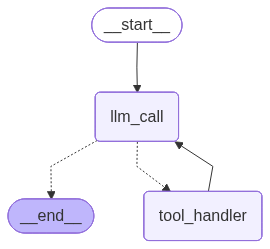

In [45]:
from langgraph.graph import StateGraph, START, END


# Build workflow
overall_workflow = StateGraph(State)

# Add nodes
overall_workflow.add_node("llm_call", llm_call)
overall_workflow.add_node("tool_handler", tool_handler)

# Add edges
overall_workflow.add_edge(START, "llm_call")
overall_workflow.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_handler": "tool_handler",
        END: END,
    },
)
overall_workflow.add_edge("tool_handler", "llm_call")

# Compile the agent
agent = overall_workflow.compile()

from IPython.display import Image, display
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

This creates a graph that:
1. Starts with an LLM decision
2. Conditionally routes to tool execution or termination
3. After tool execution, returns to LLM for the next decision
4. Repeats until completion or no tool is called


# combined classifier and agent

In [49]:
overall_workflow = (
    StateGraph(State)
    .add_node(triage_router)
    .add_node("response_agent", agent)
    .add_edge(START, "triage_router")
).compile()

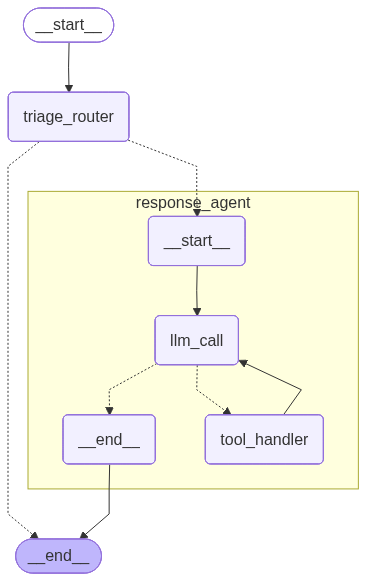

In [50]:
from IPython.display import Image, display
display(Image(overall_workflow.get_graph(xray=True).draw_mermaid_png()))

# invokation to generate response

This is a higher-level composition where:
1. First, the triage router analyzes the email
2. If needed, the response agent handles crafting a response
3. The workflow ends when either the triage decides no response is needed or the response agent completes

In [ ]:
email_input = {
    "author": "System Admin <sysadmin@company.com>",
    "to": "Development Team <dev@company.com>",
    "subject": "Scheduled maintenance - database downtime",
    "email_thread": "Hi team,\n\nThis is a reminder that we'll be performing scheduled maintenance on the production database tonight from 2AM to 4AM EST. During this time, all database services will be unavailable.\n\nPlease plan your work accordingly and ensure no critical deployments are scheduled during this window.\n\nThanks,\nSystem Admin Team"
}

# Run the agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

In [ ]:
email_input = {
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice"
}

# Run the agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

In [53]:
print(HITL_TOOLS_PROMPT)


1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Question(content) - Ask the user any follow-up questions
5. Done - E-mail has been sent



# Human feedback in the loop

In [5]:
import os
from dotenv import load_dotenv
# 1. Load variables from the .env file
load_dotenv()
OLLAMA_API_KEY = os.environ.get("OLLAMA_API_KEY")
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY")


from langchain.chat_models import init_chat_model
import os



llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)

response = llm.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)


llm2 = init_chat_model(
    "ollama:nemotron-3-super:cloud",
    base_url="https://ollama.com",
)

response = llm2.invoke(
    "What is the color of the sky answer in one word?"
)

print(response.content)

Blue
Blue


# validation models

In [7]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, Literal
from langgraph.graph import MessagesState

class RouterSchema(BaseModel):
    """Analyze the unread email and route it according to its content."""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

class StateInput(TypedDict):
    # This is the input to the state
    email_input: dict

class State(MessagesState):
    # This state class has the messages key build in
    email_input: dict
    classification_decision: Literal["ignore", "respond", "notify"]

class EmailData(TypedDict):
    id: str
    thread_id: str
    from_email: str
    subject: str
    page_content: str
    send_time: str
    to_email: str

class UserPreferences(BaseModel):
    """Updated user preferences based on user's feedback."""
    chain_of_thought: str = Field(description="Reasoning about which user preferences need to add/update if required")
    user_preferences: str = Field(description="Updated user preferences")

## tool integration

In [8]:


from typing import Literal
from datetime import datetime
from pydantic import BaseModel

from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command

# from email_assistant.prompts import triage_system_prompt, triage_user_prompt, agent_system_prompt_hitl, default_background, default_triage_instructions, default_response_preferences, default_cal_preferences
# from email_assistant.tools.default.prompt_templates import HITL_TOOLS_PROMPT
# from email_assistant.schemas import State, RouterSchema, StateInput
# from email_assistant.utils import parse_email, format_for_display, format_email_markdown

# Agent tools 
@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """Schedule a calendar meeting."""
    # Placeholder response - in real app would check calendar and schedule
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """Check calendar availability for a given day."""
    # Placeholder response - in real app would check actual calendar
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

@tool
# This is new! 
class Question(BaseModel):
      """Question to ask user."""
      content: str
    
@tool
class Done(BaseModel):
      """E-mail has been sent."""
      done: bool

# All tools available to the agent
tools = [
    write_email, 
    schedule_meeting, 
    check_calendar_availability, 
    Question, 
    Done,
]

tools_by_name = {tool.name: tool for tool in tools}

# Initialize the LLM for use with router / structured output
# llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)
llm_router = llm.with_structured_output(RouterSchema) 

# Initialize the LLM, enforcing tool use (of any available tools) for agent
# llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm = init_chat_model(
    "google_genai:gemini-2.5-flash"
)
llm_with_tools = llm.bind_tools(tools, tool_choice="required")

In [58]:
from rich.markdown import Markdown
Markdown(HITL_TOOLS_PROMPT)

 1 write_email(to, subject, content) - Send emails to specified recipients                                         
 2 schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings  
   where preferred_day is a datetime object                                                                        
 3 check_calendar_availability(day) - Check available time slots for a given day                                   
 4 Question(content) - Ask the user any follow-up questions                                                        
 5 Done - E-mail has been sent

## triage_interrupt_handler

In [9]:
def triage_interrupt_handler(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """Handles interrupts from the triage step."""
    
    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])

    # Create email markdown for Agent Inbox in case of notification  
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Create messages
    messages = [{"role": "user",
                "content": f"Email to notify user about: {email_markdown}"
                }]

    # Create interrupt that is shown to the user
    request = {
        "action_request": {
            "action": f"Email Assistant: {state['classification_decision']}",
            "args": {}
        },
        "config": {
            "allow_ignore": True,  
            "allow_respond": True, 
            "allow_edit": False, 
            "allow_accept": False,  
        },
        # Email to show in Agent Inbox
        "description": email_markdown,
    }

    # Agent Inbox responds with a list of dicts with a single key `type` that can be `accept`, `edit`, `ignore`, or `response`.  
    response = interrupt([request])[0]

    # If user provides feedback, go to response agent and use feedback to respond to email   
    if response["type"] == "response":
        # Add feedback to messages 
        user_input = response["args"]
        # Used by the response agent
        messages.append({"role": "user",
                        "content": f"User wants to reply to the email. Use this feedback to respond: {user_input}"
                        })
        # Go to response agent
        goto = "response_agent"

    # If user ignores email, go to END
    elif response["type"] == "ignore":
        goto = END

    # Catch all other responses
    else:
        raise ValueError(f"Invalid response: {response}")

    # Update the state 
    update = {
        "messages": messages,
    }

    return Command(goto=goto, update=update)

## classifier node

In [10]:
def triage_router(state: State) -> Command[Literal["triage_interrupt_handler", "response_agent", "__end__"]]:
    """Analyze email content to decide if we should respond, notify, or ignore."""

    # Parse the email input
    author, to, subject, email_thread = parse_email(state["email_input"])
    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    # Create email markdown for Agent Inbox in case of notification  
    email_markdown = format_email_markdown(subject, author, to, email_thread)

    # Format system prompt with background and triage instructions
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )

    # Run the router LLM
    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )

    # Decision
    classification = result.classification

    # Process the classification decision
    if classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        # Next node
        goto = "response_agent"
        # Update the state
        update = {
            "classification_decision": classification,
            "messages": [{"role": "user",
                            "content": f"Respond to the email: {email_markdown}"
                        }],
        }
    elif classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        # Next node
        goto = END
        # Update the state
        update = {
            "classification_decision": classification,
        }

    elif classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information") 
        # This is new! 
        goto = "triage_interrupt_handler"
        # Update the state
        update = {
            "classification_decision": classification,
        }

    else:
        raise ValueError(f"Invalid classification: {classification}")
    return Command(goto=goto, update=update)

In [63]:
print(default_cal_preferences)
print(default_response_preferences)
print(default_background)
print(HITL_TOOLS_PROMPT)


30 minute meetings are preferred, but 15 minute meetings are also acceptable.


Use professional and concise language. If the e-mail mentions a deadline, make sure to explicitly acknowledge and reference the deadline in your response.

When responding to technical questions that require investigation:
- Clearly state whether you will investigate or who you will ask
- Provide an estimated timeline for when you'll have more information or complete the task

When responding to event or conference invitations:
- Always acknowledge any mentioned deadlines (particularly registration deadlines)
- If workshops or specific topics are mentioned, ask for more specific details about them
- If discounts (group or early bird) are mentioned, explicitly request information about them
- Don't commit 

When responding to collaboration or project-related requests:
- Acknowledge any existing work or materials mentioned (drafts, slides, documents, etc.)
- Explicitly mention reviewing these materials befor

In [68]:
final_prompt = agent_system_prompt_hitl.format(tools_prompt=HITL_TOOLS_PROMPT, 
                        background=default_background,
                        response_preferences=default_response_preferences, 
                        cal_preferences=default_cal_preferences)


print(final_prompt)


< Role >
You are a top-notch executive assistant who cares about helping your executive perform as well as possible.
</ Role >

< Tools >
You have access to the following tools to help manage communications and schedule:

1. write_email(to, subject, content) - Send emails to specified recipients
2. schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings where preferred_day is a datetime object
3. check_calendar_availability(day) - Check available time slots for a given day
4. Question(content) - Ask the user any follow-up questions
5. Done - E-mail has been sent

</ Tools >

< Instructions >
When handling emails, follow these steps:
1. Carefully analyze the email content and purpose
2. IMPORTANT --- always call a tool and call one tool at a time until the task is complete: 
3. If the incoming email asks the user a direct question and you do not have context to answer the question, use the Question tool to ask the user for the answ

## llm_node

In [11]:
def llm_call(state: State):
    """LLM decides whether to call a tool or not."""

    return {
        "messages": [
            llm_with_tools.invoke(
                [
                    {"role": "system", "content": agent_system_prompt_hitl.format(tools_prompt=HITL_TOOLS_PROMPT, 
                                                                                  background=default_background,
                                                                                  response_preferences=default_response_preferences, 
                                                                                  cal_preferences=default_cal_preferences)}
                ]
                + state["messages"]
            )
        ]
    }

## interrupt_handler

In [12]:
def format_for_display(tool_call):
    """Format content for display in Agent Inbox
    
    Args:
        tool_call: The tool call to format
    """
    # Initialize empty display
    display = ""
    
    # Add tool call information
    if tool_call["name"] == "write_email":
        display += f"""# Email Draft

**To**: {tool_call["args"].get("to")}
**Subject**: {tool_call["args"].get("subject")}

{tool_call["args"].get("content")}
"""
    elif tool_call["name"] == "schedule_meeting":
        display += f"""# Calendar Invite

**Meeting**: {tool_call["args"].get("subject")}
**Attendees**: {', '.join(tool_call["args"].get("attendees"))}
**Duration**: {tool_call["args"].get("duration_minutes")} minutes
**Day**: {tool_call["args"].get("preferred_day")}
"""
    elif tool_call["name"] == "Question":
        # Special formatting for questions to make them clear
        display += f"""# Question for User

{tool_call["args"].get("content")}
"""
    else:
        # Generic format for other tools
        display += f"""# Tool Call: {tool_call["name"]}

Arguments:"""
        
        # Check if args is a dictionary or string
        if isinstance(tool_call["args"], dict):
            display += f"\n{json.dumps(tool_call['args'], indent=2)}\n"
        else:
            display += f"\n{tool_call['args']}\n"
    return display


In [13]:
def interrupt_handler(state: State) -> Command[Literal["llm_call", "__end__"]]:
    """Creates an interrupt for human review of tool calls"""
    
    # Store messages
    result = []

    # Go to the LLM call node next
    goto = "llm_call"

    # Iterate over the tool calls in the last message
    for tool_call in state["messages"][-1].tool_calls:
        
        # Allowed tools for HITL
        hitl_tools = ["write_email", "schedule_meeting", "Question"]
        
        # If tool is not in our HITL list, execute it directly without interruption
        if tool_call["name"] not in hitl_tools:

            # Execute tool without interruption
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
            continue
            
        # Get original email from email_input in state
        email_input = state["email_input"]
        author, to, subject, email_thread = parse_email(email_input)
        original_email_markdown = format_email_markdown(subject, author, to, email_thread)
        
        # Format tool call for display and prepend the original email
        tool_display = format_for_display(tool_call)
        description = original_email_markdown + tool_display

        # Configure what actions are allowed in Agent Inbox
        if tool_call["name"] == "write_email":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "schedule_meeting":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": True,
                "allow_accept": True,
            }
        elif tool_call["name"] == "Question":
            config = {
                "allow_ignore": True,
                "allow_respond": True,
                "allow_edit": False,
                "allow_accept": False,
            }
        else:
            raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # Create the interrupt request
        request = {
            "action_request": {
                "action": tool_call["name"],
                "args": tool_call["args"]
            },
            "config": config,
            "description": description,
        }

        # Send to Agent Inbox and wait for response
        response = interrupt([request])[0]

        # Handle the responses 
        if response["type"] == "accept":

            # Execute the tool with original args
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
                        
        elif response["type"] == "edit":

            # Tool selection 
            tool = tools_by_name[tool_call["name"]]
            
            # Get edited args from Agent Inbox
            edited_args = response["args"]["args"]

            # Update the AI message's tool call with edited content (reference to the message in the state)
            ai_message = state["messages"][-1] # Get the most recent message from the state
            current_id = tool_call["id"] # Store the ID of the tool call being edited
            
            # Create a new list of tool calls by filtering out the one being edited and adding the updated version
            # This avoids modifying the original list directly (immutable approach)
            updated_tool_calls = [tc for tc in ai_message.tool_calls if tc["id"] != current_id] + [
                {"type": "tool_call", "name": tool_call["name"], "args": edited_args, "id": current_id}
            ]
            
            # Create a new copy of the message with updated tool calls rather than modifying the original
            # This ensures state immutability and prevents side effects in other parts of the code
            # When we update the messages state key ("messages": result), the add_messages reducer will
            # overwrite existing messages by id and we take advantage of this here to update the tool calls.
            result.append(ai_message.model_copy(update={"tool_calls": updated_tool_calls}))

            # Update the write_email tool call with the edited content from Agent Inbox
            if tool_call["name"] == "write_email":
                
                # Execute the tool with edited args
                observation = tool.invoke(edited_args)
                
                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})
            
            # Update the schedule_meeting tool call with the edited content from Agent Inbox
            elif tool_call["name"] == "schedule_meeting":
                
                
                # Execute the tool with edited args
                observation = tool.invoke(edited_args)
                
                # Add only the tool response message
                result.append({"role": "tool", "content": observation, "tool_call_id": current_id})
            
            # Catch all other tool calls
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        elif response["type"] == "ignore":
            if tool_call["name"] == "write_email":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this email draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this calendar meeting draft. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
            elif tool_call["name"] == "Question":
                # Don't execute the tool, and tell the agent how to proceed
                result.append({"role": "tool", "content": "User ignored this question. Ignore this email and end the workflow.", "tool_call_id": tool_call["id"]})
                # Go to END
                goto = END
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")
            
        elif response["type"] == "response":
            # User provided feedback
            user_feedback = response["args"]
            if tool_call["name"] == "write_email":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the email. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            elif tool_call["name"] == "schedule_meeting":
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User gave feedback, which can we incorporate into the meeting request. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            elif tool_call["name"] == "Question": 
                # Don't execute the tool, and add a message with the user feedback to incorporate into the email
                result.append({"role": "tool", "content": f"User answered the question, which can we can use for any follow up actions. Feedback: {user_feedback}", "tool_call_id": tool_call["id"]})
            else:
                raise ValueError(f"Invalid tool call: {tool_call['name']}")

        # Catch all other responses
        else:
            raise ValueError(f"Invalid response: {response}")
            
    # Update the state 
    update = {
        "messages": result,
    }

    return Command(goto=goto, update=update)

In [14]:
# from email_assistant.utils import show_graph
# Conditional edge function
def should_continue(state: State) -> Literal["interrupt_handler", "__end__"]:
    """Route to tool handler, or end if Done tool called"""
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "interrupt_handler"


C:\Users\smrit\AppData\Local\Temp\ipykernel_23680\3002156329.py:24: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  StateGraph(State, input=StateInput)


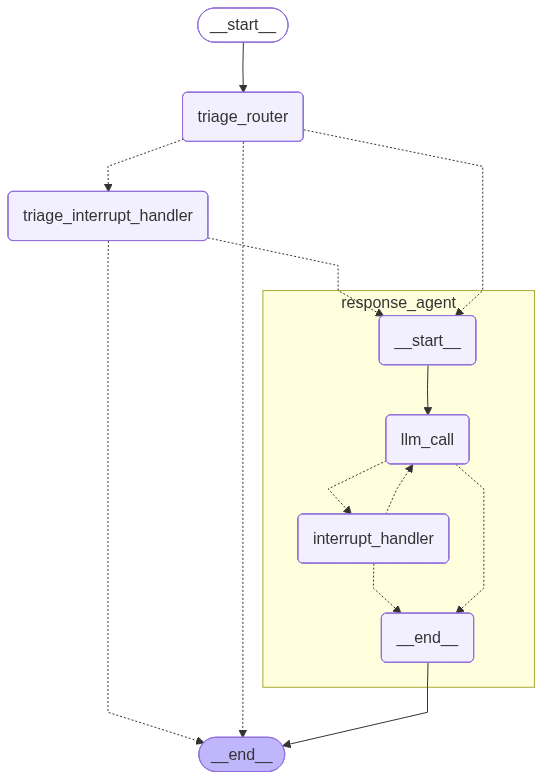

In [15]:
# Build workflow
agent_builder = StateGraph(State)

# Add nodes
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("interrupt_handler", interrupt_handler)

# Add edges
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "interrupt_handler": "interrupt_handler",
        END: END,
    },
)

# Compile the agent
response_agent = agent_builder.compile()

# Build overall workflow
overall_workflow = (
    StateGraph(State, input=StateInput)
    .add_node(triage_router)
    .add_node(triage_interrupt_handler)
    .add_node("response_agent", response_agent)
    .add_edge(START, "triage_router")
    
)

email_assistant = overall_workflow.compile()
# show_graph(email_assistant, xray=True)


from IPython.display import Image, display
display(Image(email_assistant.get_graph(xray=True).draw_mermaid_png()))

# execution with interupts

In [16]:
import uuid
from langgraph.checkpoint.memory import InMemorySaver

# Email to respond to
email_input_respond = {
    "to": "Lance Martin <lance@company.com>",
    "author": "Project Manager <pm@client.com>",
    "subject": "Tax season let's schedule call",
    "email_thread": "Lance,\n\nIt's tax season again, and I wanted to schedule a call to discuss your tax planning strategies for this year. I have some suggestions that could potentially save you money.\n\nAre you available sometime next week? Tuesday or Thursday afternoon would work best for me, for about 45 minutes.\n\nRegards,\nProject Manager"
}

# Compile the graph with checkpointer
checkpointer = InMemorySaver()
graph = overall_workflow.compile(checkpointer=checkpointer)
thread_id_1 = uuid.uuid4()
thread_config_1 = {"configurable": {"thread_id": thread_id_1}}

# Run the graph until a tool call that we choose to interrupt
print("Running the graph until the first interrupt...")
for chunk in graph.stream({"email_input": email_input_respond}, config=thread_config_1):
    # Inspect interrupt object if present
    if '__interrupt__' in chunk:
        Interrupt_Object = chunk['__interrupt__'][0]
        print("\nINTERRUPT OBJECT:")
        print(f"Action Request: {Interrupt_Object.value[0]['action_request']}")

Running the graph until the first interrupt...


📧 Classification: RESPOND - This email requires a response


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 9.230456267s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTi

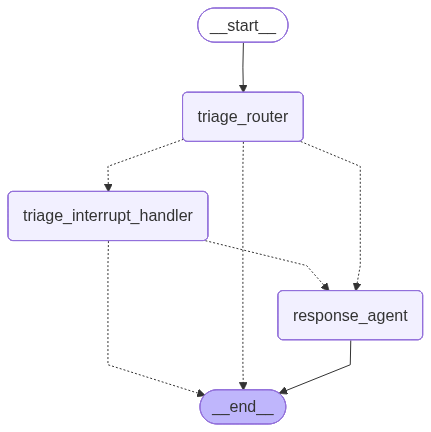

In [17]:
graph